# Preprocessing Verification

## Purpose
Before training any model, we visually verify that:

1. The data generators load images and labels correctly
2. Pixel values are properly normalized to [0.0 – 1.0]
3. Augmentation looks reasonable — variations are subtle,
   tissue structure is preserved, nothing is destroyed
4. Class indices are mapped correctly

This notebook imports directly from `src/data_preprocessing.py`,
so whatever we verify here is exactly what the training script will use.

## Step 1 — Imports and Path Setup

In [1]:
import os
os.add_dll_directory(r"C:\Users\ahmed\anaconda3\envs\lung_cancer\Library\bin")

import sys
import numpy as np
import matplotlib.pyplot as plt

# Add the project root to Python's path so we can import from src/
# Our notebook lives in notebooks/ — we go one level up to reach the root
sys.path.append(os.path.abspath(".."))

from src.data_preprocessing import get_data_generators, IMG_SIZE, BATCH_SIZE

print("✅ Imports successful.")
print(f"   Default image size : {IMG_SIZE}")
print(f"   Default batch size : {BATCH_SIZE}")

✅ Imports successful.
   Default image size : (224, 224)
   Default batch size : 32


## Step 2 — Build the Generators

We call `get_data_generators()` which will print a summary of how many
images ended up in each split.

In [2]:
DATA_DIR = r"../data/lung_image_sets"

train_gen, val_gen, test_gen = get_data_generators(
    data_dir   = DATA_DIR,
    img_size   = IMG_SIZE,
    batch_size = BATCH_SIZE
)

# Verify the split is exactly what we expect
total = train_gen.n + val_gen.n + test_gen.n
print(f"\nSplit verification:")
print(f"  Train : {train_gen.n:,}  ({train_gen.n/total*100:.1f}%)  → expected 70%")
print(f"  Val   : {val_gen.n:,}   ({val_gen.n/total*100:.1f}%)  → expected 15%")
print(f"  Test  : {test_gen.n:,}   ({test_gen.n/total*100:.1f}%)  → expected 15%")
print(f"  Total : {total:,}")


Found 10500 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
Found 2250 validated image filenames belonging to 3 classes.
──────────────────────────────────────────────────
  Data Generators Ready
──────────────────────────────────────────────────
  Image size     : 224 × 224 px
  Batch size     : 32
  Train samples  : 10500
  Val   samples  : 2250
  Test  samples  : 2250
  Classes        : {'lung_aca': 0, 'lung_n': 1, 'lung_scc': 2}
──────────────────────────────────────────────────

Split verification:
  Train : 10,500  (70.0%)  → expected 70%
  Val   : 2,250   (15.0%)  → expected 15%
  Test  : 2,250   (15.0%)  → expected 15%
  Total : 15,000


## Step 3 — Verify Class Mapping

The generator assigns a numeric index to each class folder automatically
(alphabetical order). We need to confirm the mapping is what we expect:

| Index | Class folder | Meaning |
|-------|-------------|---------|
| 0 | lung_aca | Lung Adenocarcinoma |
| 1 | lung_n   | Normal              |
| 2 | lung_scc | Squamous Cell Carcinoma |

This mapping must stay consistent across training, evaluation, and the UI.

In [3]:
print("Class index mapping:")
for class_name, index in train_gen.class_indices.items():
    print(f"  {index}  →  {class_name}")

Class index mapping:
  0  →  lung_aca
  1  →  lung_n
  2  →  lung_scc


## Step 4 — Verify Pixel Normalization

After rescaling, all pixel values should be in the range [0.0, 1.0].
We grab one batch from the training generator and check the min and max
pixel values to confirm normalization worked correctly.

In [4]:
# Pull one batch of images and labels from the training generator
images_batch, labels_batch = next(train_gen)

print(f"Batch shape   : {images_batch.shape}")
# Expected: (32, 224, 224, 3)
# → 32 images, 224×224 pixels, 3 color channels (R, G, B)

print(f"Labels shape  : {labels_batch.shape}")
# Expected: (32, 3)
# → 32 one-hot encoded labels, one per class

print(f"Pixel min     : {images_batch.min():.4f}   (should be ≥ 0.0)")
print(f"Pixel max     : {images_batch.max():.4f}   (should be ≤ 1.0)")
print(f"Pixel dtype   : {images_batch.dtype}")      # should be float32

print("\nSample label (first image in batch):", labels_batch[0])
# e.g. [1. 0. 0.] = lung_aca,  [0. 1. 0.] = lung_n,  [0. 0. 1.] = lung_scc

Batch shape   : (32, 224, 224, 3)
Labels shape  : (32, 3)
Pixel min     : 0.0000   (should be ≥ 0.0)
Pixel max     : 1.0000   (should be ≤ 1.0)
Pixel dtype   : float32

Sample label (first image in batch): [0. 0. 1.]


## Step 5 — Visual Augmentation Check

This is the most important verification step.

We display the same image passed through the augmentation pipeline
multiple times — each time the generator applies a different random
combination of flip, rotation, zoom, and brightness.

What we're looking for:
- The tissue structure is still clearly visible
- No extreme distortions or color inversions
- Variations look like natural microscopy differences, not noise

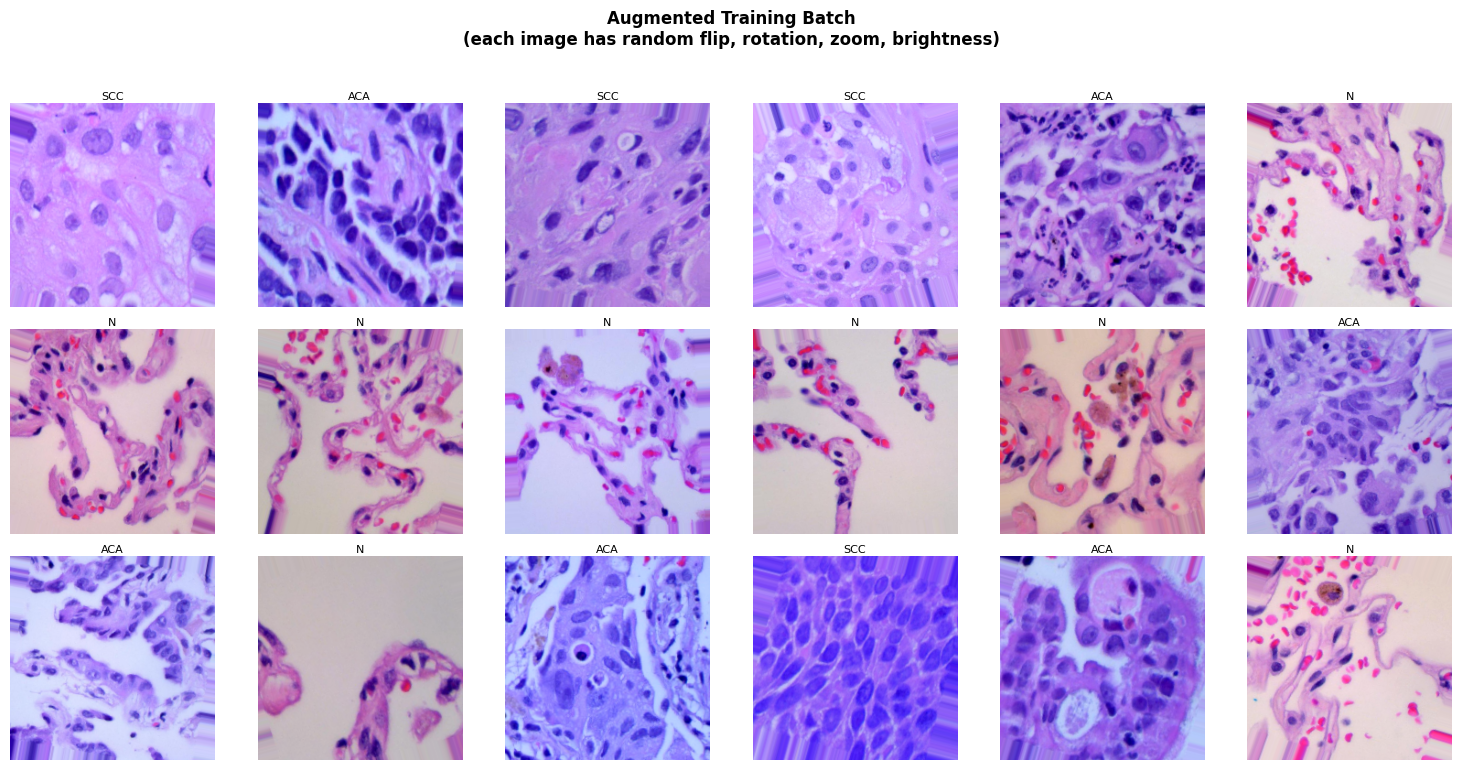

💾 Saved → results/preprocessing_augmentation_check.png


In [5]:
# Human-readable class name lookup (reverse of class_indices)
index_to_class = {v: k for k, v in train_gen.class_indices.items()}

CLASS_DISPLAY = {
    "lung_aca": "Lung Adenocarcinoma",
    "lung_n"  : "Normal",
    "lung_scc": "Squamous Cell Carcinoma"
}

# ── Show 3 rows × 6 columns of augmented training images ─────────────────
ROWS, COLS = 3, 6

fig, axes = plt.subplots(ROWS, COLS, figsize=(COLS * 2.5, ROWS * 2.5))

# We need a fresh batch — call next() again to get a new random batch
images_batch, labels_batch = next(train_gen)

for i, ax in enumerate(axes.flat):
    if i >= len(images_batch):
        ax.axis("off")
        continue

    ax.imshow(images_batch[i])
    ax.axis("off")

    # Convert one-hot label → class index → folder name → display name
    class_idx  = np.argmax(labels_batch[i])
    folder     = index_to_class[class_idx]
    short_name = folder.replace("lung_", "").upper()  # e.g. "ACA", "N", "SCC"
    ax.set_title(short_name, fontsize=8, pad=2)

plt.suptitle(
    "Augmented Training Batch\n(each image has random flip, rotation, zoom, brightness)",
    fontsize=12, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("../results/preprocessing_augmentation_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/preprocessing_augmentation_check.png")

## Step 6 — Verify Validation and Test Batches are Clean

We confirm that validation and test batches have NO augmentation —
pixel values should look identical to the original images (just resized
and normalized), with no random flips or rotations applied.

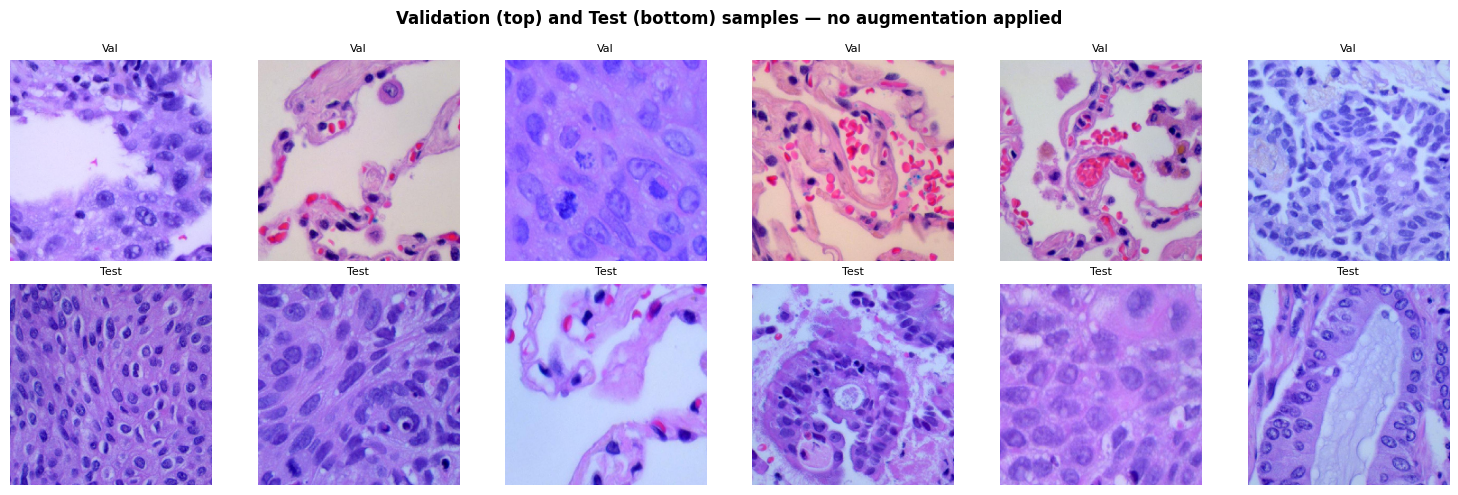

💾 Saved → results/preprocessing_val_test_check.png


In [6]:
val_images,  val_labels  = next(val_gen)
test_images, test_labels = next(test_gen)

fig, axes = plt.subplots(2, 6, figsize=(15, 5))

for i in range(6):
    axes[0, i].imshow(val_images[i])
    axes[0, i].axis("off")
    axes[0, i].set_title("Val", fontsize=8)

    axes[1, i].imshow(test_images[i])
    axes[1, i].axis("off")
    axes[1, i].set_title("Test", fontsize=8)

plt.suptitle(
    "Validation (top) and Test (bottom) samples — no augmentation applied",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.savefig("../results/preprocessing_val_test_check.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved → results/preprocessing_val_test_check.png")

## Summary

| Check | Expected | Status |
|---|---|---|
| Train samples | ~10,500 | ✅ Verify from generator output above |
| Val samples | ~2,250 | ✅ Verify from generator output above |
| Test samples | ~2,250 | ✅ Verify from generator output above |
| Pixel range | [0.0 – 1.0] | ✅ Verified in Step 4 |
| Batch shape | (32, 224, 224, 3) | ✅ Verified in Step 4 |
| Label shape | (32, 3) one-hot | ✅ Verified in Step 4 |
| Augmentation visible on train | Yes — subtle | ✅ Verified in Step 5 |
| Val / Test — no augmentation | Yes — clean | ✅ Verified in Step 6 |

## What Comes Next — Phase 3: Baseline CNN

With preprocessing confirmed and working, we build a simple CNN
from scratch as our benchmark model. This gives us a baseline
accuracy score that all transfer learning models must beat.